In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’

In [4]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "20.5.+featureCounts$", full.names = T)

f_files


[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts"
 [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts"
 [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts"
 [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts"        
 [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts"        
 [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts"        
 [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts"      
 [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts"      
 [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts"      
[10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts"    
[11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts"    
[12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts"    
[13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts"    
[14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts"    
[15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts"    
[16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts"  
[17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts"  
[18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts"  
[19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts"   
[20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts"   
[21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts"   
[22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts"      
[23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts"      
[24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts"      
[25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts"     
[26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts"     
[27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts"     
[28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts"     
[29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts"     
[30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.f

In [5]:
f_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts')

f_files

[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts"
 [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts"
 [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts"
 [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts"        
 [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts"        
 [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts"        
 [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts"      
 [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts"      
 [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts"      
[10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts"    
[11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts"    
[12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts"    
[13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts"    
[14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts"    
[15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts"    
[16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts"  
[17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts"  
[18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts"  
[19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts"   
[20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts"   
[21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts"   
[22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts"      
[23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts"      
[24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts"      
[25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts"     
[26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts"     
[27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts"     
[28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts"     
[29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts"     
[30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.f

In [6]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [4] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [7] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
[10] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
[13] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
[16] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
[19] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
[22] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
[25] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
[28] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
[31] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[34] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[37] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[40] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [7]:
samplenames <- c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','A_J-P20.5','A_J-P20.5','A_J-P20.5','AKR_J-P20.5',
'AKR_J-P20.5','AKR_J-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CBA_J-P20.5',
'CBA_J-P20.5','CBA_J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

In [8]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [4] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [7] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
[10] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
[13] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
[16] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
[19] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
[22] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
[25] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
[28] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
[31] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[34] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[37] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[40] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [9]:
lables <- c('129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3','A_J-P20.5.1',
'A_J-P20.5.2','A_J-P20.5.3','AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3','BALB_cJ-P20.5.1',
'BALB_cJ-P20.5.2','BALB_cJ-P20.5.3','C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3','C57BL_6NJ-P20.5.1',
'C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3','CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3','CBA_J-P20.5.1',
'CBA_J-P20.5.2','CBA_J-P20.5.3','DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3','FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3','SPRET_EiJ-P20.5.1',
'SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3','WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

In [10]:
#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames_order = c('C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

In [11]:
#list of sample names with replicates 
#lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))
lables_order = c('C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3',
'A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3',
'129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

In [12]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/129S1_SvImJ_v3.2.gff3") #import gff3 file 
A129S1_SvImJ <- na.omit(mcols(A129S1_SvImJ)[,c("gene_id","parent_gene_display_xref",'type')])
A129S1_SvImJ <- A129S1_SvImJ[A129S1_SvImJ$type == 'gene', ]
A129S1_SvImJ
A129S1_SvImJ_geneName = A129S1_SvImJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(A129S1_SvImJ_geneName) <- A129S1_SvImJ_geneName$gene_id
A129S1_SvImJ_geneName$gene_id <- NULL
A129S1_SvImJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts')
#A129S1_SvImJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
A129S1_SvImJ_samplenames = c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5')

A129S1_SvImJ_lables = c('129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3')
A129S1_SvImJ_raw <- readDGE(A129S1_SvImJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= A129S1_SvImJ_samplenames, labels = A129S1_SvImJ_lables)

library(dplyr)
A129S1_SvImJ_raw$counts <- merge(x=A129S1_SvImJ_raw$counts, y=A129S1_SvImJ_geneName, by = 0,all.x=TRUE ) #left merge 
A129S1_SvImJ_raw$counts['Row.names'] <- NULL
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts[!is.na(A129S1_SvImJ_raw$counts$parent_gene_display_xref),] #remove NA 
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

A129S1_SvImJ_raw$counts <- as.data.frame(A129S1_SvImJ_raw$counts[!duplicated(A129S1_SvImJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(A129S1_SvImJ_raw$counts) <- A129S1_SvImJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
A129S1_SvImJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
A129S1_SvImJ_raw

DataFrame with 25181 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00200053149                   Ugt1a1     gene
2     ENSMUSG00200032800            4933401J01Rik     gene
3     ENSMUSG00200032797                     Xkr4     gene
4     ENSMUSG00200032798                  Gm37180     gene
5     ENSMUSG00200032795                  Gm37363     gene
...                  ...                      ...      ...
25177 ENSMUSG00200046500                  Arhgap6     gene
25178 ENSMUSG00200046501                    Amelx     gene
25179 ENSMUSG00200046496                     Hccs     gene
25180 ENSMUSG00200025986                     Mid1     gene
25181 ENSMUSG00200025979            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                             files
129S1_SvImJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts
129S1_SvImJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts
129S1_SvImJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts
                                group lib.size norm.factors
129S1_SvImJ-P20.5.1 129S1_SvImJ-P20.5 31695878            1
129S1_SvImJ-P20.5.2 129S1_SvImJ-P20.5 34592855            1
129S1_SvImJ-P20.5.3 129S1_SvImJ-P20.5 31849719            1

$counts
              129S1_SvImJ-P20.5.1 129S1_SvImJ-P20.5.2 129S1_SvImJ-P20.5.3
0610009B22Rik               918.0             1021.00               710.0
0610010K14Rik               435.0              423.00               394.0
0610012G03Rik               630.0              661.00               576.0
0610030E20Rik              2007.0             2100.00              2055.0
0610040J01Rik                29.7               46.65                30.4
24564 more rows ...

In [13]:
A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/A_J_v3.2.gff3") #import gff3 file 
A_J <- na.omit(mcols(A_J)[,c("gene_id","parent_gene_display_xref",'type')])
A_J <- A_J[A_J$type == 'gene', ]
A_J
A_J_geneName = A_J[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(A_J_geneName) <- A_J_geneName$gene_id
A_J_geneName$gene_id <- NULL
A_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts')
#A_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "A_J.+.featureCounts$", full.names = T)
A_J_samplenames = c('A_J-P20.5','A_J-P20.5','A_J-P20.5')

A_J_lables = c('A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3')
A_J_raw <- readDGE(A_J_files, columns = c(1, 7), comment.char = "#", sep="\t", group= A_J_samplenames, labels = A_J_lables)

library(dplyr)
A_J_raw$counts <- merge(x=A_J_raw$counts, y=A_J_geneName, by = 0,all.x=TRUE ) #left merge 
A_J_raw$counts['Row.names'] <- NULL
A_J_raw$counts <- A_J_raw$counts[!is.na(A_J_raw$counts$parent_gene_display_xref),] #remove NA 
A_J_raw$counts <- A_J_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

A_J_raw$counts <- as.data.frame(A_J_raw$counts[!duplicated(A_J_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(A_J_raw$counts) <- A_J_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
A_J_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
A_J_raw

DataFrame with 25310 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00195027922            4933401J01Rik     gene
2     ENSMUSG00195027925                     Xkr4     gene
3     ENSMUSG00195027926                  Gm37180     gene
4     ENSMUSG00195027927                  Gm37363     gene
5     ENSMUSG00195027924                  Gm37686     gene
...                  ...                      ...      ...
25306 ENSMUSG00195023491                  Arhgap6     gene
25307 ENSMUSG00195023492                    Amelx     gene
25308 ENSMUSG00195023487                     Hccs     gene
25309 ENSMUSG00195023371                     Mid1     gene
25310 ENSMUSG00195023364            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                             files
A_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts
A_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts
A_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts
                group lib.size norm.factors
A_J-P20.5.1 A_J-P20.5 31363174            1
A_J-P20.5.2 A_J-P20.5 30304673            1
A_J-P20.5.3 A_J-P20.5 28304885            1

$counts
              A_J-P20.5.1 A_J-P20.5.2 A_J-P20.5.3
0610009B22Rik       809.0       660.0      630.00
0610010K14Rik       470.5       462.5      451.00
0610012G03Rik       564.5       491.5      508.00
0610030E20Rik      1771.0      1688.0     1500.00
0610040J01Rik        17.0        28.0       26.11
24607 more rows ...

In [14]:
AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
AKR_J <- na.omit(mcols(AKR_J)[,c("gene_id","parent_gene_display_xref",'type')])
AKR_J <- AKR_J[AKR_J$type == 'gene', ]
AKR_J
AKR_J_geneName = AKR_J[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(AKR_J_geneName) <- AKR_J_geneName$gene_id
AKR_J_geneName$gene_id <- NULL
AKR_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts')
#AKR_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
AKR_J_samplenames = c('AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5')

AKR_J_lables = c('AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3')

AKR_J_raw <- readDGE(AKR_J_files, columns = c(1, 7), comment.char = "#", sep="\t", group= AKR_J_samplenames, labels = AKR_J_lables)
AKR_J_raw
library(dplyr)
AKR_J_raw$counts <- merge(x=AKR_J_raw$counts, y=AKR_J_geneName, by = 0,all.x=TRUE ) #left merge 
AKR_J_raw$counts['Row.names'] <- NULL
AKR_J_raw$counts <- AKR_J_raw$counts[!is.na(AKR_J_raw$counts$parent_gene_display_xref),] #remove NA 
AKR_J_raw$counts <- AKR_J_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

AKR_J_raw$counts <- as.data.frame(AKR_J_raw$counts[!duplicated(AKR_J_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(AKR_J_raw$counts) <- AKR_J_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
AKR_J_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
AKR_J_raw

DataFrame with 25028 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00220052967                  Gm37665     gene
2     ENSMUSG00220035080            4933401J01Rik     gene
3     ENSMUSG00220035076                     Xkr4     gene
4     ENSMUSG00220035077                  Gm37180     gene
5     ENSMUSG00220035078                  Gm37363     gene
...                  ...                      ...      ...
25024 ENSMUSG00220031275                  Arhgap6     gene
25025 ENSMUSG00220031276                    Amelx     gene
25026 ENSMUSG00220031271                     Hccs     gene
25027 ENSMUSG00220029997                     Mid1     gene
25028 ENSMUSG00220029990            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                 files
AKR_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts
AKR_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts
AKR_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts
                    group lib.size norm.factors
AKR_J-P20.5.1 AKR_J-P20.5 34053358            1
AKR_J-P20.5.2 AKR_J-P20.5 33420664            1
AKR_J-P20.5.3 AKR_J-P20.5 29358964            1

$counts
                    Samples
Tags                 AKR_J-P20.5.1 AKR_J-P20.5.2 AKR_J-P20.5.3
  ENSMUSG00220052967          0.64          0.28          1.05
  ENSMUSG00220035080          0.00          0.00          0.00
  ENSMUSG00220035076        220.95        257.73        230.94
  ENSMUSG00220035077          0.50          0.50          3.00
  ENSMUSG00220035078          1.50          2.00          0.00
25077 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                 files
AKR_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts
AKR_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts
AKR_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts
                    group lib.size norm.factors
AKR_J-P20.5.1 AKR_J-P20.5 34053358            1
AKR_J-P20.5.2 AKR_J-P20.5 33420664            1
AKR_J-P20.5.3 AKR_J-P20.5 29358964            1

$counts
              AKR_J-P20.5.1 AKR_J-P20.5.2 AKR_J-P20.5.3
0610009B22Rik         879.0         872.0        785.50
0610010K14Rik         466.0         492.5        435.00
0610012G03Rik         901.5         857.5        836.50
0610030E20Rik        1761.0        1713.0       1630.00
0610040J01Rik          37.0          37.0         25.06
24480 more rows ...

In [15]:
BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/BALB_cJ_v3.2.gff3") #import gff3 file 
BALB_cJ <- na.omit(mcols(BALB_cJ)[,c("gene_id","parent_gene_display_xref",'type')])
BALB_cJ <- BALB_cJ[BALB_cJ$type == 'gene', ]
BALB_cJ
BALB_cJ_geneName = BALB_cJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(BALB_cJ_geneName) <- BALB_cJ_geneName$gene_id
BALB_cJ_geneName$gene_id <- NULL
BALB_cJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts')
#BALB_cJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
BALB_cJ_samplenames = c('BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5')

BALB_cJ_lables = c('BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3')

BALB_cJ_raw <- readDGE(BALB_cJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= BALB_cJ_samplenames, labels = BALB_cJ_lables)
BALB_cJ_raw
library(dplyr)
BALB_cJ_raw$counts <- merge(x=BALB_cJ_raw$counts, y=BALB_cJ_geneName, by = 0,all.x=TRUE ) #left merge 
BALB_cJ_raw$counts['Row.names'] <- NULL
BALB_cJ_raw$counts <- BALB_cJ_raw$counts[!is.na(BALB_cJ_raw$counts$parent_gene_display_xref),] #remove NA 
BALB_cJ_raw$counts <- BALB_cJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

BALB_cJ_raw$counts <- as.data.frame(BALB_cJ_raw$counts[!duplicated(BALB_cJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(BALB_cJ_raw$counts) <- BALB_cJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
BALB_cJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
BALB_cJ_raw

DataFrame with 25265 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00180035131            4933401J01Rik     gene
2     ENSMUSG00180049956            4933401J01Rik     gene
3     ENSMUSG00180035136                     Xkr4     gene
4     ENSMUSG00180049961                     Xkr4     gene
5     ENSMUSG00180035137                  Gm37180     gene
...                  ...                      ...      ...
25261 ENSMUSG00180029632                    Amelx     gene
25262 ENSMUSG00180029627                     Hccs     gene
25263 ENSMUSG00180030566                     Mid1     gene
25264 ENSMUSG00180030559            4933400A11Rik     gene
25265 ENSMUSG00180010232                     Asmt     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
BALB_cJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts
BALB_cJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts
BALB_cJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
BALB_cJ-P20.5.1 BALB_cJ-P20.5 29820486            1
BALB_cJ-P20.5.2 BALB_cJ-P20.5 31571935            1
BALB_cJ-P20.5.3 BALB_cJ-P20.5 32204352            1

$counts
                    Samples
Tags                 BALB_cJ-P20.5.1 BALB_cJ-P20.5.2 BALB_cJ-P20.5.3
  ENSMUSG00180035131            0.00            0.00            0.00
  ENSMUSG00180049956            0.00            0.00            0.00
  ENSMUSG00180035136          415.44          448.06          286.58
  ENSMUSG00180049961          415.44          448.06          286.58
  ENSMUSG00180035137            1.75            3.75            1.75
25317 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
BALB_cJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.1.featureCounts
BALB_cJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.2.featureCounts
BALB_cJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
BALB_cJ-P20.5.1 BALB_cJ-P20.5 29820486            1
BALB_cJ-P20.5.2 BALB_cJ-P20.5 31571935            1
BALB_cJ-P20.5.3 BALB_cJ-P20.5 32204352            1

$counts
              BALB_cJ-P20.5.1 BALB_cJ-P20.5.2 BALB_cJ-P20.5.3
0610009B22Rik           599.0          530.00             724
0610010K14Rik           616.5          646.00             634
0610012G03Rik           448.5          470.50             516
0610030E20Rik          1185.0         1207.00            1323
0610040J01Rik            38.0           73.25              43
24617 more rows ...

In [16]:
C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C3H_HeJ_v3.2.gff3") #import gff3 file 
C3H_HeJ <- na.omit(mcols(C3H_HeJ)[,c("gene_id","parent_gene_display_xref",'type')])
C3H_HeJ <- C3H_HeJ[C3H_HeJ$type == 'gene', ]
C3H_HeJ
C3H_HeJ_geneName = C3H_HeJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(C3H_HeJ_geneName) <- C3H_HeJ_geneName$gene_id
C3H_HeJ_geneName$gene_id <- NULL
C3H_HeJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts')
#C3H_HeJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C3H_HeJ_samplenames = c('C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5')

C3H_HeJ_lables = c('C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3')

C3H_HeJ_raw <- readDGE(C3H_HeJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= C3H_HeJ_samplenames, labels = C3H_HeJ_lables)
C3H_HeJ_raw
library(dplyr)
C3H_HeJ_raw$counts <- merge(x=C3H_HeJ_raw$counts, y=C3H_HeJ_geneName, by = 0,all.x=TRUE ) #left merge 
C3H_HeJ_raw$counts['Row.names'] <- NULL
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts[!is.na(C3H_HeJ_raw$counts$parent_gene_display_xref),] #remove NA 
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

C3H_HeJ_raw$counts <- as.data.frame(C3H_HeJ_raw$counts[!duplicated(C3H_HeJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(C3H_HeJ_raw$counts) <- C3H_HeJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
C3H_HeJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
C3H_HeJ_raw

DataFrame with 25234 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00175052656            4933401J01Rik     gene
2     ENSMUSG00175052660                     Xkr4     gene
3     ENSMUSG00175052661                  Gm37180     gene
4     ENSMUSG00175052658                  Gm37363     gene
5     ENSMUSG00175052657                  Gm37686     gene
...                  ...                      ...      ...
25230 ENSMUSG00175024741                  Arhgap6     gene
25231 ENSMUSG00175024742                    Amelx     gene
25232 ENSMUSG00175024737                     Hccs     gene
25233 ENSMUSG00175025067                     Mid1     gene
25234 ENSMUSG00175025060            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
C3H_HeJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts
C3H_HeJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts
C3H_HeJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
C3H_HeJ-P20.5.1 C3H_HeJ-P20.5 30194559            1
C3H_HeJ-P20.5.2 C3H_HeJ-P20.5 31131475            1
C3H_HeJ-P20.5.3 C3H_HeJ-P20.5 28906617            1

$counts
                    Samples
Tags                 C3H_HeJ-P20.5.1 C3H_HeJ-P20.5.2 C3H_HeJ-P20.5.3
  ENSMUSG00175000077            4.08            7.00            6.25
  ENSMUSG00175000075            0.83            0.75            3.50
  ENSMUSG00175000074            0.33            0.00            0.50
  ENSMUSG00175001026            1.00            1.00            2.83
  ENSMUSG00175053343            6.88            6.53           12.25
25288 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
C3H_HeJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.1.featureCounts
C3H_HeJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.2.featureCounts
C3H_HeJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
C3H_HeJ-P20.5.1 C3H_HeJ-P20.5 30194559            1
C3H_HeJ-P20.5.2 C3H_HeJ-P20.5 31131475            1
C3H_HeJ-P20.5.3 C3H_HeJ-P20.5 28906617            1

$counts
              C3H_HeJ-P20.5.1 C3H_HeJ-P20.5.2 C3H_HeJ-P20.5.3
0610009B22Rik           792.0           816.0             718
0610010K14Rik           369.0           407.5             392
0610012G03Rik           520.0           522.5             514
0610030E20Rik          1914.5          2022.0            1872
0610040J01Rik            20.0            22.0              26
24591 more rows ...

In [17]:
C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C57BL_6NJ_v3.2.gff3") #import gff3 file 
C57BL_6NJ <- na.omit(mcols(C57BL_6NJ)[,c("gene_id","parent_gene_display_xref",'type')])
C57BL_6NJ <- C57BL_6NJ[C57BL_6NJ$type == 'gene', ]
C57BL_6NJ
C57BL_6NJ_geneName = C57BL_6NJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(C57BL_6NJ_geneName) <- C57BL_6NJ_geneName$gene_id
C57BL_6NJ_geneName$gene_id <- NULL
C57BL_6NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts')
#C57BL_6NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C57BL_6NJ_samplenames = c('C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5')

C57BL_6NJ_lables = c('C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3')

C57BL_6NJ_raw <- readDGE(C57BL_6NJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= C57BL_6NJ_samplenames, labels = C57BL_6NJ_lables)
C57BL_6NJ_raw
library(dplyr)
C57BL_6NJ_raw$counts <- merge(x=C57BL_6NJ_raw$counts, y=C57BL_6NJ_geneName, by = 0,all.x=TRUE ) #left merge 
C57BL_6NJ_raw$counts['Row.names'] <- NULL
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts[!is.na(C57BL_6NJ_raw$counts$parent_gene_display_xref),] #remove NA 
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

C57BL_6NJ_raw$counts <- as.data.frame(C57BL_6NJ_raw$counts[!duplicated(C57BL_6NJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(C57BL_6NJ_raw$counts) <- C57BL_6NJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
C57BL_6NJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
C57BL_6NJ_raw

DataFrame with 25416 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00215026942            4933401J01Rik     gene
2     ENSMUSG00215026945                     Xkr4     gene
3     ENSMUSG00215026946                  Gm37180     gene
4     ENSMUSG00215026947                  Gm37363     gene
5     ENSMUSG00215026944                  Gm37686     gene
...                  ...                      ...      ...
25412 ENSMUSG00215046477                  Arhgap6     gene
25413 ENSMUSG00215046478                    Amelx     gene
25414 ENSMUSG00215046473                     Hccs     gene
25415 ENSMUSG00215046985                     Mid1     gene
25416 ENSMUSG00215046973            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                         files
C57BL_6NJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts
C57BL_6NJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts
C57BL_6NJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
C57BL_6NJ-P20.5.1 C57BL_6NJ-P20.5 30901648            1
C57BL_6NJ-P20.5.2 C57BL_6NJ-P20.5 33194713            1
C57BL_6NJ-P20.5.3 C57BL_6NJ-P20.5 31873705            1

$counts
                    Samples
Tags                 C57BL_6NJ-P20.5.1 C57BL_6NJ-P20.5.2 C57BL_6NJ-P20.5.3
  ENSMUSG00215026942              0.00              0.00              1.00
  ENSMUSG00215026945            473.66            314.24            300.26
  ENSMUSG00215026946              3.50              0.50              2.50
  ENSMUSG00215026947              2.50              1.00              0.00
  ENSMUSG00215026944              1.50              0.00              0.50
25464 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
C57BL_6NJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.1.featureCounts
C57BL_6NJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.2.featureCounts
C57BL_6NJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
C57BL_6NJ-P20.5.1 C57BL_6NJ-P20.5 30901648            1
C57BL_6NJ-P20.5.2 C57BL_6NJ-P20.5 33194713            1
C57BL_6NJ-P20.5.3 C57BL_6NJ-P20.5 31873705            1

$counts
              C57BL_6NJ-P20.5.1 C57BL_6NJ-P20.5.2 C57BL_6NJ-P20.5.3
0610009B22Rik             610.0            790.00            812.00
0610010K14Rik             437.0            466.00            412.50
0610012G03Rik             520.5            605.50            625.50
0610030E20Rik            1602.0           1762.00           1541.00
0610040J01Rik              43.4             61.77             34.06
24671 more rows ...

In [18]:
CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CAST_EiJ_v3.2.gff3") #import gff3 file 
CAST_EiJ <- na.omit(mcols(CAST_EiJ)[,c("gene_id","parent_gene_display_xref",'type')])
CAST_EiJ <- CAST_EiJ[CAST_EiJ$type == 'gene', ]
CAST_EiJ
CAST_EiJ_geneName = CAST_EiJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(CAST_EiJ_geneName) <- CAST_EiJ_geneName$gene_id
CAST_EiJ_geneName$gene_id <- NULL
CAST_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts')
#CAST_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CAST_EiJ_samplenames = c('CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5')

CAST_EiJ_lables = c('CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3')

CAST_EiJ_raw <- readDGE(CAST_EiJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= CAST_EiJ_samplenames, labels = CAST_EiJ_lables)
CAST_EiJ_raw
library(dplyr)
CAST_EiJ_raw$counts <- merge(x=CAST_EiJ_raw$counts, y=CAST_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
CAST_EiJ_raw$counts['Row.names'] <- NULL
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts[!is.na(CAST_EiJ_raw$counts$parent_gene_display_xref),] #remove NA 
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

CAST_EiJ_raw$counts <- as.data.frame(CAST_EiJ_raw$counts[!duplicated(CAST_EiJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(CAST_EiJ_raw$counts) <- CAST_EiJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
CAST_EiJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
CAST_EiJ_raw

DataFrame with 24839 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00010052158                  Gm37697     gene
2     ENSMUSG00010052160                    Hjurp     gene
3     ENSMUSG00010037506            4933401J01Rik     gene
4     ENSMUSG00010037512                     Xkr4     gene
5     ENSMUSG00010037513                  Gm37180     gene
...                  ...                      ...      ...
24835 ENSMUSG00010033644                    Amelx     gene
24836 ENSMUSG00010033638                     Hccs     gene
24837 ENSMUSG00010053198                     Prc1     gene
24838 ENSMUSG00010041892                     Mid1     gene
24839 ENSMUSG00010041889            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                       files
CAST_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts
CAST_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts
CAST_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts
                          group lib.size norm.factors
CAST_EiJ-P20.5.1 CAST_EiJ-P20.5 29673050            1
CAST_EiJ-P20.5.2 CAST_EiJ-P20.5 29461142            1
CAST_EiJ-P20.5.3 CAST_EiJ-P20.5 30427187            1

$counts
                    Samples
Tags                 CAST_EiJ-P20.5.1 CAST_EiJ-P20.5.2 CAST_EiJ-P20.5.3
  ENSMUSG00010000120             3.75             2.83            12.00
  ENSMUSG00010013800             0.88             8.08             7.92
  ENSMUSG00010000116             0.38             1.75             0.92
  ENSMUSG00010006800             0.38             1.75             0.92
  ENSMUSG00010000119             7.62            16.33            11.20
24900 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                       files
CAST_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.1.featureCounts
CAST_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.2.featureCounts
CAST_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-20.5dpp.3.featureCounts
                          group lib.size norm.factors
CAST_EiJ-P20.5.1 CAST_EiJ-P20.5 29673050            1
CAST_EiJ-P20.5.2 CAST_EiJ-P20.5 29461142            1
CAST_EiJ-P20.5.3 CAST_EiJ-P20.5 30427187            1

$counts
              CAST_EiJ-P20.5.1 CAST_EiJ-P20.5.2 CAST_EiJ-P20.5.3
0610009B22Rik            530.0           469.00            404.0
0610010K14Rik            454.0           493.00            641.0
0610012G03Rik            424.5           392.50            443.0
0610030E20Rik           1367.5          1072.00           1083.5
0610040J01Rik             86.5           115.61            100.5
24426 more rows ...

In [19]:
CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CBA_J_v3.2.gff3") #import gff3 file 
CBA_J <- na.omit(mcols(CBA_J)[,c("gene_id","parent_gene_display_xref",'type')])
CBA_J <- CBA_J[CBA_J$type == 'gene', ]
CBA_J
CBA_J_geneName = CBA_J[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(CBA_J_geneName) <- CBA_J_geneName$gene_id
CBA_J_geneName$gene_id <- NULL
CBA_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts')
#CBA_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CBA_J_samplenames = c('CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5')

CBA_J_lables = c('CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3')

CBA_J_raw <- readDGE(CBA_J_files, columns = c(1, 7), comment.char = "#", sep="\t", group= CBA_J_samplenames, labels = CBA_J_lables)
CBA_J_raw
library(dplyr)
CBA_J_raw$counts <- merge(x=CBA_J_raw$counts, y=CBA_J_geneName, by = 0,all.x=TRUE ) #left merge 
CBA_J_raw$counts['Row.names'] <- NULL
CBA_J_raw$counts <- CBA_J_raw$counts[!is.na(CBA_J_raw$counts$parent_gene_display_xref),] #remove NA 
CBA_J_raw$counts <- CBA_J_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

CBA_J_raw$counts <- as.data.frame(CBA_J_raw$counts[!duplicated(CBA_J_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(CBA_J_raw$counts) <- CBA_J_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
CBA_J_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
CBA_J_raw

DataFrame with 25082 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00210039749            4933401J01Rik     gene
2     ENSMUSG00210039751                     Xkr4     gene
3     ENSMUSG00210039753                  Gm37180     gene
4     ENSMUSG00210039754                  Gm37363     gene
5     ENSMUSG00210039750                  Gm37686     gene
...                  ...                      ...      ...
25078 ENSMUSG00210029270                  Arhgap6     gene
25079 ENSMUSG00210029271                    Amelx     gene
25080 ENSMUSG00210029266                     Hccs     gene
25081 ENSMUSG00210030698                     Mid1     gene
25082 ENSMUSG00210030691            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                 files
CBA_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts
CBA_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts
CBA_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts
                    group lib.size norm.factors
CBA_J-P20.5.1 CBA_J-P20.5 35083606            1
CBA_J-P20.5.2 CBA_J-P20.5 31495165            1
CBA_J-P20.5.3 CBA_J-P20.5 32084396            1

$counts
                    Samples
Tags                 CBA_J-P20.5.1 CBA_J-P20.5.2 CBA_J-P20.5.3
  ENSMUSG00210039749          0.00          0.00           0.0
  ENSMUSG00210039751        529.79        415.36         467.4
  ENSMUSG00210039753          3.00          4.00           2.0
  ENSMUSG00210039754          2.50          2.50           1.0
  ENSMUSG00210039750          2.00          2.00           0.0
25131 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                 files
CBA_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.1.featureCounts
CBA_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.2.featureCounts
CBA_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-20.5dpp.3.featureCounts
                    group lib.size norm.factors
CBA_J-P20.5.1 CBA_J-P20.5 35083606            1
CBA_J-P20.5.2 CBA_J-P20.5 31495165            1
CBA_J-P20.5.3 CBA_J-P20.5 32084396            1

$counts
              CBA_J-P20.5.1 CBA_J-P20.5.2 CBA_J-P20.5.3
0610009B22Rik         712.0         699.0         615.0
0610010K14Rik         602.5         495.5         519.0
0610012G03Rik         584.5         573.0         466.5
0610030E20Rik        1751.0        1619.0        1584.0
0610040J01Rik          41.0          37.0          34.0
24528 more rows ...

In [20]:
DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/DBA_2J_v3.2.gff3") #import gff3 file 
DBA_2J <- na.omit(mcols(DBA_2J)[,c("gene_id","parent_gene_display_xref",'type')])
DBA_2J <- DBA_2J[DBA_2J$type == 'gene', ]
DBA_2J
DBA_2J_geneName = DBA_2J[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(DBA_2J_geneName) <- DBA_2J_geneName$gene_id
DBA_2J_geneName$gene_id <- NULL
DBA_2J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts')
#DBA_2J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
DBA_2J_samplenames = c('DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5')

DBA_2J_lables = c('DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3')

DBA_2J_raw <- readDGE(DBA_2J_files, columns = c(1, 7), comment.char = "#", sep="\t", group= DBA_2J_samplenames, labels = DBA_2J_lables)
DBA_2J_raw
library(dplyr)
DBA_2J_raw$counts <- merge(x=DBA_2J_raw$counts, y=DBA_2J_geneName, by = 0,all.x=TRUE ) #left merge 
DBA_2J_raw$counts['Row.names'] <- NULL
DBA_2J_raw$counts <- DBA_2J_raw$counts[!is.na(DBA_2J_raw$counts$parent_gene_display_xref),] #remove NA 
DBA_2J_raw$counts <- DBA_2J_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

DBA_2J_raw$counts <- as.data.frame(DBA_2J_raw$counts[!duplicated(DBA_2J_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(DBA_2J_raw$counts) <- DBA_2J_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
DBA_2J_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
DBA_2J_raw

DataFrame with 25838 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00185054966                   Ugt1a1     gene
2     ENSMUSG00185054967                  Gm37665     gene
3     ENSMUSG00185054968                    Hjurp     gene
4     ENSMUSG00185054969                   Ugt1a1     gene
5     ENSMUSG00185049753            4933401J01Rik     gene
...                  ...                      ...      ...
25834 ENSMUSG00185022637                  Arhgap6     gene
25835 ENSMUSG00185022638                    Amelx     gene
25836 ENSMUSG00185022633                     Hccs     gene
25837 ENSMUSG00185023796                     Mid1     gene
25838 ENSMUSG00185023791            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                   files
DBA_2J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts
DBA_2J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts
DBA_2J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts
                      group lib.size norm.factors
DBA_2J-P20.5.1 DBA_2J-P20.5 31537573            1
DBA_2J-P20.5.2 DBA_2J-P20.5 31061727            1
DBA_2J-P20.5.3 DBA_2J-P20.5 32682992            1

$counts
                    Samples
Tags                 DBA_2J-P20.5.1 DBA_2J-P20.5.2 DBA_2J-P20.5.3
  ENSMUSG00185054966          24.33          13.67          21.83
  ENSMUSG00185054967           0.51           0.83           1.15
  ENSMUSG00185054968         917.20         841.83         904.57
  ENSMUSG00185054969          48.83          41.67          53.83
  ENSMUSG00185049753           0.00           0.00           0.00
25975 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                   files
DBA_2J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.1.featureCounts
DBA_2J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.2.featureCounts
DBA_2J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-20.5dpp.3.featureCounts
                      group lib.size norm.factors
DBA_2J-P20.5.1 DBA_2J-P20.5 31537573            1
DBA_2J-P20.5.2 DBA_2J-P20.5 31061727            1
DBA_2J-P20.5.3 DBA_2J-P20.5 32682992            1

$counts
              DBA_2J-P20.5.1 DBA_2J-P20.5.2 DBA_2J-P20.5.3
0610009B22Rik          724.0            836          859.0
0610010K14Rik          518.5            470          501.5
0610012G03Rik          555.0            558          624.0
0610030E20Rik         1861.0           2009         2086.0
0610040J01Rik           21.5             20           14.0
24873 more rows ...

In [21]:
FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/FVB_NJ_v3.2.gff3") #import gff3 file 
FVB_NJ <- na.omit(mcols(FVB_NJ)[,c("gene_id","parent_gene_display_xref",'type')])
FVB_NJ <- FVB_NJ[FVB_NJ$type == 'gene', ]
FVB_NJ
FVB_NJ_geneName = FVB_NJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(FVB_NJ_geneName) <- FVB_NJ_geneName$gene_id
FVB_NJ_geneName$gene_id <- NULL
FVB_NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts')
#FVB_NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
FVB_NJ_samplenames = c('FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5')

FVB_NJ_lables = c('FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3')

FVB_NJ_raw <- readDGE(FVB_NJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= FVB_NJ_samplenames, labels = FVB_NJ_lables)
FVB_NJ_raw
library(dplyr)
FVB_NJ_raw$counts <- merge(x=FVB_NJ_raw$counts, y=FVB_NJ_geneName, by = 0,all.x=TRUE ) #left merge 
FVB_NJ_raw$counts['Row.names'] <- NULL
FVB_NJ_raw$counts <- FVB_NJ_raw$counts[!is.na(FVB_NJ_raw$counts$parent_gene_display_xref),] #remove NA 
FVB_NJ_raw$counts <- FVB_NJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

FVB_NJ_raw$counts <- as.data.frame(FVB_NJ_raw$counts[!duplicated(FVB_NJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(FVB_NJ_raw$counts) <- FVB_NJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
FVB_NJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
FVB_NJ_raw

DataFrame with 24950 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00205029548            4933401J01Rik     gene
2     ENSMUSG00205029545                     Xkr4     gene
3     ENSMUSG00205029546                  Gm37180     gene
4     ENSMUSG00205029543                  Gm37363     gene
5     ENSMUSG00205029542                  Gm37686     gene
...                  ...                      ...      ...
24946 ENSMUSG00205024065                  Arhgap6     gene
24947 ENSMUSG00205024066                    Amelx     gene
24948 ENSMUSG00205024061                     Hccs     gene
24949 ENSMUSG00205044709                     Mid1     gene
24950 ENSMUSG00205044702            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                   files
FVB_NJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts
FVB_NJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts
FVB_NJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts
                      group lib.size norm.factors
FVB_NJ-P20.5.1 FVB_NJ-P20.5 31526666            1
FVB_NJ-P20.5.2 FVB_NJ-P20.5 31491413            1
FVB_NJ-P20.5.3 FVB_NJ-P20.5 30377947            1

$counts
                    Samples
Tags                 FVB_NJ-P20.5.1 FVB_NJ-P20.5.2 FVB_NJ-P20.5.3
  ENSMUSG00205029548           0.00           0.00           0.00
  ENSMUSG00205029545         190.77         244.86         343.42
  ENSMUSG00205029546           0.00           1.50           3.50
  ENSMUSG00205029543           0.50           2.50           1.50
  ENSMUSG00205029542           0.00           0.50           0.00
25002 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                   files
FVB_NJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.1.featureCounts
FVB_NJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.2.featureCounts
FVB_NJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-20.5dpp.3.featureCounts
                      group lib.size norm.factors
FVB_NJ-P20.5.1 FVB_NJ-P20.5 31526666            1
FVB_NJ-P20.5.2 FVB_NJ-P20.5 31491413            1
FVB_NJ-P20.5.3 FVB_NJ-P20.5 30377947            1

$counts
              FVB_NJ-P20.5.1 FVB_NJ-P20.5.2 FVB_NJ-P20.5.3
0610009B22Rik          690.0          701.0         623.00
0610010K14Rik          491.5          513.0         494.50
0610012G03Rik          465.5          451.5         478.00
0610030E20Rik         1573.0         1634.0        1463.50
0610040J01Rik           32.5           29.0          26.17
24361 more rows ...

In [22]:
NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NOD_ShiLtJ_v3.2.gff3") #import gff3 file 
NOD_ShiLtJ <- na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","parent_gene_display_xref",'type')])
NOD_ShiLtJ <- NOD_ShiLtJ[NOD_ShiLtJ$type == 'gene', ]
NOD_ShiLtJ
NOD_ShiLtJ_geneName = NOD_ShiLtJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(NOD_ShiLtJ_geneName) <- NOD_ShiLtJ_geneName$gene_id
NOD_ShiLtJ_geneName$gene_id <- NULL
NOD_ShiLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts')
#NOD_ShiLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NOD_ShiLtJ_samplenames = c('NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5')

NOD_ShiLtJ_lables = c('NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3')

NOD_ShiLtJ_raw <- readDGE(NOD_ShiLtJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= NOD_ShiLtJ_samplenames, labels = NOD_ShiLtJ_lables)
NOD_ShiLtJ_raw
library(dplyr)
NOD_ShiLtJ_raw$counts <- merge(x=NOD_ShiLtJ_raw$counts, y=NOD_ShiLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NOD_ShiLtJ_raw$counts['Row.names'] <- NULL
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts[!is.na(NOD_ShiLtJ_raw$counts$parent_gene_display_xref),] #remove NA 
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

NOD_ShiLtJ_raw$counts <- as.data.frame(NOD_ShiLtJ_raw$counts[!duplicated(NOD_ShiLtJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(NOD_ShiLtJ_raw$counts) <- NOD_ShiLtJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
NOD_ShiLtJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
NOD_ShiLtJ_raw

DataFrame with 25167 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00190029111            4933401J01Rik     gene
2     ENSMUSG00190029107                     Xkr4     gene
3     ENSMUSG00190029108                  Gm37180     gene
4     ENSMUSG00190029109                  Gm37363     gene
5     ENSMUSG00190029106                  Gm37686     gene
...                  ...                      ...      ...
25163 ENSMUSG00190025601                    Amelx     gene
25164 ENSMUSG00190025596                     Hccs     gene
25165 ENSMUSG00190024932                     Mid1     gene
25166 ENSMUSG00190024924            4933400A11Rik     gene
25167 ENSMUSG00190042617                     Asmt     gene

An object of class "DGEList"
$samples
                                                                                                                                           files
NOD_ShiLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts
NOD_ShiLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts
NOD_ShiLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts
                              group lib.size norm.factors
NOD_ShiLtJ-P20.5.1 NOD_ShiLtJ-P20.5 30661013            1
NOD_ShiLtJ-P20.5.2 NOD_ShiLtJ-P20.5 34702200            1
NOD_ShiLtJ-P20.5.3 NOD_ShiLtJ-P20.5 36690017            1

$counts
                    Samples
Tags                 NOD_ShiLtJ-P20.5.1 NOD_ShiLtJ-P20.5.2 NOD_ShiLtJ-P20.5.3
  ENSMUSG00190029111               0.00               0.00               2.00
  ENSMUSG00190029107             458.08             488.09             294.79
  ENSMUSG00190029108               2.50               3.00               1.00
  ENSMUSG00190029109               2.00               1.50               1.00
  ENSMUSG00190029106               1.00               0.00               1.00
25201 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                           files
NOD_ShiLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.1.featureCounts
NOD_ShiLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.2.featureCounts
NOD_ShiLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-20.5dpp.3.featureCounts
                              group lib.size norm.factors
NOD_ShiLtJ-P20.5.1 NOD_ShiLtJ-P20.5 30661013            1
NOD_ShiLtJ-P20.5.2 NOD_ShiLtJ-P20.5 34702200            1
NOD_ShiLtJ-P20.5.3 NOD_ShiLtJ-P20.5 36690017            1

$counts
              NOD_ShiLtJ-P20.5.1 NOD_ShiLtJ-P20.5.2 NOD_ShiLtJ-P20.5.3
0610009B22Rik              553.0                609             1051.0
0610010K14Rik              555.0                615              415.0
0610012G03Rik              407.5                429              655.0
0610030E20Rik             1187.0               1389             2108.0
0610040J01Rik               31.0                 42               15.5
24481 more rows ...

In [23]:
PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/PWK_PhJ_v3.2.gff3") #import gff3 file 
PWK_PhJ <- na.omit(mcols(PWK_PhJ)[,c("gene_id","parent_gene_display_xref",'type')])
PWK_PhJ <- PWK_PhJ[PWK_PhJ$type == 'gene', ]
PWK_PhJ
PWK_PhJ_geneName = PWK_PhJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(PWK_PhJ_geneName) <- PWK_PhJ_geneName$gene_id
PWK_PhJ_geneName$gene_id <- NULL
PWK_PhJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts')
#PWK_PhJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
PWK_PhJ_samplenames = c('PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5')

PWK_PhJ_lables = c('PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3')

PWK_PhJ_raw <- readDGE(PWK_PhJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= PWK_PhJ_samplenames, labels = PWK_PhJ_lables)
PWK_PhJ_raw
library(dplyr)
PWK_PhJ_raw$counts <- merge(x=PWK_PhJ_raw$counts, y=PWK_PhJ_geneName, by = 0,all.x=TRUE ) #left merge 
PWK_PhJ_raw$counts['Row.names'] <- NULL
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts[!is.na(PWK_PhJ_raw$counts$parent_gene_display_xref),] #remove NA 
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

PWK_PhJ_raw$counts <- as.data.frame(PWK_PhJ_raw$counts[!duplicated(PWK_PhJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(PWK_PhJ_raw$counts) <- PWK_PhJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
PWK_PhJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
PWK_PhJ_raw

DataFrame with 25045 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00010051178            4933401J01Rik     gene
2     ENSMUSG00010051174                     Xkr4     gene
3     ENSMUSG00010051175                  Gm37180     gene
4     ENSMUSG00010051176                  Gm37363     gene
5     ENSMUSG00010051173                  Gm37686     gene
...                  ...                      ...      ...
25041 ENSMUSG00010049861                    Amelx     gene
25042 ENSMUSG00010049856                     Hccs     gene
25043 ENSMUSG00010021797                     Mid1     gene
25044 ENSMUSG00010053526                  Gm47025     gene
25045 ENSMUSG00010021790            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
PWK_PhJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts
PWK_PhJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts
PWK_PhJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
PWK_PhJ-P20.5.1 PWK_PhJ-P20.5 33240796            1
PWK_PhJ-P20.5.2 PWK_PhJ-P20.5 34620023            1
PWK_PhJ-P20.5.3 PWK_PhJ-P20.5 32306239            1

$counts
                    Samples
Tags                 PWK_PhJ-P20.5.1 PWK_PhJ-P20.5.2 PWK_PhJ-P20.5.3
  ENSMUSG00010051178             0.0            0.00            0.00
  ENSMUSG00010051174           495.2          574.17          470.63
  ENSMUSG00010051175             2.5            2.00            5.50
  ENSMUSG00010051176             2.0            4.00            3.00
  ENSMUSG00010051173             1.0            1.00            0.00
25108 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
PWK_PhJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.1.featureCounts
PWK_PhJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.2.featureCounts
PWK_PhJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
PWK_PhJ-P20.5.1 PWK_PhJ-P20.5 33240796            1
PWK_PhJ-P20.5.2 PWK_PhJ-P20.5 34620023            1
PWK_PhJ-P20.5.3 PWK_PhJ-P20.5 32306239            1

$counts
              PWK_PhJ-P20.5.1 PWK_PhJ-P20.5.2 PWK_PhJ-P20.5.3
0610009B22Rik         1113.00         1101.00         1087.00
0610010K14Rik          555.50          534.00          461.50
0610012G03Rik          425.50          447.00          401.00
0610030E20Rik         2223.00         2411.00         2025.00
0610040J01Rik           58.69           62.25           39.94
24432 more rows ...

In [24]:
SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/SPRET_EiJ_v3.2.gff3") #import gff3 file 
SPRET_EiJ <- na.omit(mcols(SPRET_EiJ)[,c("gene_id","parent_gene_display_xref",'type')])
SPRET_EiJ <- SPRET_EiJ[SPRET_EiJ$type == 'gene', ]
SPRET_EiJ
SPRET_EiJ_geneName = SPRET_EiJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(SPRET_EiJ_geneName) <- SPRET_EiJ_geneName$gene_id
SPRET_EiJ_geneName$gene_id <- NULL
SPRET_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts')
#SPRET_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
SPRET_EiJ_samplenames = c('SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

SPRET_EiJ_lables = c('SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

SPRET_EiJ_raw <- readDGE(SPRET_EiJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= SPRET_EiJ_samplenames, labels = SPRET_EiJ_lables)
SPRET_EiJ_raw
library(dplyr)
SPRET_EiJ_raw$counts <- merge(x=SPRET_EiJ_raw$counts, y=SPRET_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
SPRET_EiJ_raw$counts['Row.names'] <- NULL
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts[!is.na(SPRET_EiJ_raw$counts$parent_gene_display_xref),] #remove NA 
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

SPRET_EiJ_raw$counts <- as.data.frame(SPRET_EiJ_raw$counts[!duplicated(SPRET_EiJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(SPRET_EiJ_raw$counts) <- SPRET_EiJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
SPRET_EiJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
SPRET_EiJ_raw

DataFrame with 24730 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMSPG00010049827            4933401J01Rik     gene
2     ENSMSPG00010049830                     Xkr4     gene
3     ENSMSPG00010049831                  Gm37180     gene
4     ENSMSPG00010049832                  Gm37363     gene
5     ENSMSPG00010049829                  Gm37686     gene
...                  ...                      ...      ...
24726 ENSMSPG00010038985                  Arhgap6     gene
24727 ENSMSPG00010038979                    Amelx     gene
24728 ENSMSPG00010038981                     Hccs     gene
24729 ENSMSPG00010019823                     Mid1     gene
24730 ENSMSPG00010019820            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                         files
SPRET_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts
SPRET_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts
SPRET_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
SPRET_EiJ-P20.5.1 SPRET_EiJ-P20.5 31526585            1
SPRET_EiJ-P20.5.2 SPRET_EiJ-P20.5 30967101            1
SPRET_EiJ-P20.5.3 SPRET_EiJ-P20.5 28341229            1

$counts
                    Samples
Tags                 SPRET_EiJ-P20.5.1 SPRET_EiJ-P20.5.2 SPRET_EiJ-P20.5.3
  ENSMSPG00010049827              0.00              0.00              0.00
  ENSMSPG00010049830           1023.41            838.25            701.65
  ENSMSPG00010049831              5.50              7.00              5.00
  ENSMSPG00010049832              5.00              4.50              4.50
  ENSMSPG00010049829              2.50              0.00              2.00
24775 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
SPRET_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.1.featureCounts
SPRET_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.2.featureCounts
SPRET_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
SPRET_EiJ-P20.5.1 SPRET_EiJ-P20.5 31526585            1
SPRET_EiJ-P20.5.2 SPRET_EiJ-P20.5 30967101            1
SPRET_EiJ-P20.5.3 SPRET_EiJ-P20.5 28341229            1

$counts
              SPRET_EiJ-P20.5.1 SPRET_EiJ-P20.5.2 SPRET_EiJ-P20.5.3
0610009B22Rik            476.00            496.00            462.00
0610010K14Rik            761.00            793.50            763.50
0610012G03Rik            344.67            390.00            337.67
0610030E20Rik            824.50           1088.00            970.00
0610040J01Rik             22.00             20.03             18.00
24230 more rows ...

In [25]:
WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/WSB_EiJ_v3.2.gff3") #import gff3 file 
WSB_EiJ <- na.omit(mcols(WSB_EiJ)[,c("gene_id","parent_gene_display_xref",'type')])
WSB_EiJ <- WSB_EiJ[WSB_EiJ$type == 'gene', ]
WSB_EiJ
WSB_EiJ_geneName = WSB_EiJ[,c("gene_id","parent_gene_display_xref")] #get gene symbloes for respective gene id 
rownames(WSB_EiJ_geneName) <- WSB_EiJ_geneName$gene_id
WSB_EiJ_geneName$gene_id <- NULL
WSB_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts')
#WSB_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
WSB_EiJ_samplenames = c('WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

WSB_EiJ_lables = c('WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

WSB_EiJ_raw <- readDGE(WSB_EiJ_files, columns = c(1, 7), comment.char = "#", sep="\t", group= WSB_EiJ_samplenames, labels = WSB_EiJ_lables)
WSB_EiJ_raw
library(dplyr)
WSB_EiJ_raw$counts <- merge(x=WSB_EiJ_raw$counts, y=WSB_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
WSB_EiJ_raw$counts['Row.names'] <- NULL
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts[!is.na(WSB_EiJ_raw$counts$parent_gene_display_xref),] #remove NA 
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

WSB_EiJ_raw$counts <- as.data.frame(WSB_EiJ_raw$counts[!duplicated(WSB_EiJ_raw$counts$parent_gene_display_xref), ])  #remove dulicate values 
rownames(WSB_EiJ_raw$counts) <- WSB_EiJ_raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
WSB_EiJ_raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 
WSB_EiJ_raw

DataFrame with 24913 rows and 3 columns
                 gene_id parent_gene_display_xref     type
             <character>              <character> <factor>
1     ENSMUSG00010052547                  Gm10717     gene
2     ENSMUSG00010037591            4933401J01Rik     gene
3     ENSMUSG00010037594                     Xkr4     gene
4     ENSMUSG00010037595                  Gm37180     gene
5     ENSMUSG00010037596                  Gm37363     gene
...                  ...                      ...      ...
24909 ENSMUSG00010031592                  Arhgap6     gene
24910 ENSMUSG00010031593                    Amelx     gene
24911 ENSMUSG00010031588                     Hccs     gene
24912 ENSMUSG00010023781                     Mid1     gene
24913 ENSMUSG00010023774            4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
WSB_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts
WSB_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts
WSB_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
WSB_EiJ-P20.5.1 WSB_EiJ-P20.5 33645623            1
WSB_EiJ-P20.5.2 WSB_EiJ-P20.5 31610458            1
WSB_EiJ-P20.5.3 WSB_EiJ-P20.5 31257792            1

$counts
                    Samples
Tags                 WSB_EiJ-P20.5.1 WSB_EiJ-P20.5.2 WSB_EiJ-P20.5.3
  ENSMUSG00010052547            8.55           19.87           23.82
  ENSMUSG00010037591            0.00            0.00            0.00
  ENSMUSG00010037594          532.99          326.36          425.36
  ENSMUSG00010037595            2.50            1.50            2.00
  ENSMUSG00010037596            1.00            0.50            2.00
24959 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
WSB_EiJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.1.featureCounts
WSB_EiJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.2.featureCounts
WSB_EiJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-20.5dpp.3.featureCounts
                        group lib.size norm.factors
WSB_EiJ-P20.5.1 WSB_EiJ-P20.5 33645623            1
WSB_EiJ-P20.5.2 WSB_EiJ-P20.5 31610458            1
WSB_EiJ-P20.5.3 WSB_EiJ-P20.5 31257792            1

$counts
              WSB_EiJ-P20.5.1 WSB_EiJ-P20.5.2 WSB_EiJ-P20.5.3
0610009B22Rik           587.0           594.0           617.0
0610010K14Rik           537.0           506.0           492.5
0610012G03Rik           485.5           468.0           462.5
0610030E20Rik          1573.0          1047.0          1159.0
0610040J01Rik            31.0            40.3            34.0
24377 more rows ...

In [26]:
library(edgeR)

# Combine two DGEList objects
# Assuming you have a list of DGEList objects: dge_list
dge_list <- list(A129S1_SvImJ_raw, A_J_raw,AKR_J_raw, BALB_cJ_raw,
    C3H_HeJ_raw,C57BL_6NJ_raw,CAST_EiJ_raw,CBA_J_raw,DBA_2J_raw,FVB_NJ_raw,NOD_ShiLtJ_raw,PWK_PhJ_raw,WSB_EiJ_raw,SPRET_EiJ_raw)  # List of DGEList objects
gene_lists <- lapply(dge_list, rownames)

# Find common genes across all gene lists
common_genes <- Reduce(intersect, gene_lists)


all_strains_dge <- cbind(A129S1_SvImJ_raw$counts[common_genes,], A_J_raw$counts[common_genes,],AKR_J_raw$counts[common_genes,], 
        BALB_cJ_raw$counts[common_genes,],C3H_HeJ_raw$counts[common_genes,],C57BL_6NJ_raw$counts[common_genes,],CAST_EiJ_raw$counts[common_genes,],
        CBA_J_raw$counts[common_genes,],DBA_2J_raw$counts[common_genes,],FVB_NJ_raw$counts[common_genes,],NOD_ShiLtJ_raw$counts[common_genes,],
        PWK_PhJ_raw$counts[common_genes,],WSB_EiJ_raw$counts[common_genes,],SPRET_EiJ_raw$counts[common_genes,])
all_strains_dge

,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P20.5.1,A_J-P20.5.2,A_J-P20.5.3,AKR_J-P20.5.1,AKR_J-P20.5.2,AKR_J-P20.5.3,BALB_cJ-P20.5.1,⋯,NOD_ShiLtJ-P20.5.3,PWK_PhJ-P20.5.1,PWK_PhJ-P20.5.2,PWK_PhJ-P20.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3,SPRET_EiJ-P20.5.1,SPRET_EiJ-P20.5.2,SPRET_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610009B22Rik,918.00,1021.00,710.00,809.00,660.00,630.00,879.00,872.00,785.50,599.00,⋯,1051.00,1113.00,1101.00,1087.00,587.00,594.00,617.00,476.00,496.00,462.00
0610010K14Rik,435.00,423.00,394.00,470.50,462.50,451.00,466.00,492.50,435.00,616.50,⋯,415.00,555.50,534.00,461.50,537.00,506.00,492.50,761.00,793.50,763.50
0610012G03Rik,630.00,661.00,576.00,564.50,491.50,508.00,901.50,857.50,836.50,448.50,⋯,655.00,425.50,447.00,401.00,485.50,468.00,462.50,344.67,390.00,337.67
0610030E20Rik,2007.00,2100.00,2055.00,1771.00,1688.00,1500.00,1761.00,1713.00,1630.00,1185.00,⋯,2108.00,2223.00,2411.00,2025.00,1573.00,1047.00,1159.00,824.50,1088.00,970.00
0610040J01Rik,29.70,46.65,30.40,17.00,28.00,26.11,37.00,37.00,25.06,38.00,⋯,15.50,58.69,62.25,39.94,31.00,40.30,34.00,22.00,20.03,18.00
1110002E22Rik,2.00,3.17,3.00,2.00,2.00,2.00,2.50,2.00,3.00,0.00,⋯,1.00,1.00,1.00,2.00,2.00,0.00,3.00,2.00,0.00,1.00
1110003F10Rik,5.00,10.00,8.50,7.50,8.50,5.00,9.50,10.50,11.00,11.50,⋯,8.00,21.00,13.00,17.00,15.50,11.50,7.50,18.00,16.50,19.00
1110004F10Rik,4139.53,4323.50,4335.33,4560.17,4464.52,4064.40,4694.00,4408.17,3784.42,3976.68,⋯,5341.76,4457.50,4691.00,4499.25,4102.45,3931.64,3838.40,3559.10,3911.50,3695.66
1110017D15Rik,374.50,473.33,342.00,367.28,320.00,252.40,458.90,457.70,402.08,206.93,⋯,930.17,247.00,273.50,276.50,141.33,67.00,56.50,62.00,138.71,176.00


In [27]:
combined_dge <- DGEList(counts = all_strains_dge)


samplenames <- c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
    'A_J-P20.5','A_J-P20.5','A_J-P20.5',
    'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
    'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
   'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
    'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
    'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
    'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
    'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')


combined_dge$samples$group <- samplenames

combined_dge$samples

,group,lib.size,norm.factors
,<chr>,<dbl>,<dbl>
129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5,31043823,1
129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5,33882264,1
129S1_SvImJ-P20.5.3,129S1_SvImJ-P20.5,31213568,1
A_J-P20.5.1,A_J-P20.5,30861918,1
A_J-P20.5.2,A_J-P20.5,29819513,1
A_J-P20.5.3,A_J-P20.5,27888420,1
AKR_J-P20.5.1,AKR_J-P20.5,33389911,1
AKR_J-P20.5.2,AKR_J-P20.5,32753427,1
AKR_J-P20.5.3,AKR_J-P20.5,28774217,1


In [28]:
rawdata_copy <-combined_dge
#colnames(LP_J_geneName)[which(names(LP_J_geneName) == "Name")] <- "parent_gene_display_xref" #change columns name
#colnames(NZO_HlLtJ_geneName)[which(names(NZO_HlLtJ_geneName) == "Name")] <- "parent_gene_display_xref" # change column name 

In [29]:
#rawdata_copy$counts <- ifelse(is.na(rawdata_copy$counts), 0, rawdata_copy$counts)
dge <- DGEList(counts =combined_dge$counts)
# Filtering
keep <- rowSums(dge$counts) >= 16
dge <- dge[keep, ]
#dge <- calcNormFactors(rawdata_copy)
# Calculate scaling factors using TMM
scaling_factors <- calcNormFactors(dge, method = "TMM")
# Normalize the counts using the calculated scaling factors
#dge_normalized <- dge
#dge_normalized$samples$norm.factors <- scaling_factors
norm_counts <- cpm(scaling_factors)

In [30]:
norm_counts

,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P20.5.1,A_J-P20.5.2,A_J-P20.5.3,AKR_J-P20.5.1,AKR_J-P20.5.2,AKR_J-P20.5.3,BALB_cJ-P20.5.1,⋯,NOD_ShiLtJ-P20.5.3,PWK_PhJ-P20.5.1,PWK_PhJ-P20.5.2,PWK_PhJ-P20.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3,SPRET_EiJ-P20.5.1,SPRET_EiJ-P20.5.2,SPRET_EiJ-P20.5.3
0610009B22Rik,33.14448451,33.93561255,24.34111647,26.79297896,22.79153949,22.48899831,27.29690884,27.78404411,28.73710623,18.70338393,⋯,31.99424737,33.02216524,32.17926873,34.65882140,17.70636429,18.55336164,19.32837402,13.80249781,14.9373473,15.18736101
0610010K14Rik,15.70571978,14.05951431,13.50760548,15.58231965,15.97134396,16.09926704,14.47139877,15.69224968,15.91424724,19.24981000,⋯,12.63331366,16.48141311,15.60738375,14.71485379,16.19815609,15.80471547,15.42824020,22.06659840,23.8967441,25.09859335
0610012G03Rik,22.74621486,21.97006846,19.74715928,18.69547172,16.97279039,18.13398594,27.99563517,27.32203879,30.60291452,14.00411968,⋯,19.93932638,12.62437674,13.06460774,12.78582096,14.64470164,14.61780008,14.48844892,9.99434227,11.7450916,11.10025150
0610030E20Rik,72.46294162,69.79900720,70.45210471,58.65310968,58.29108888,53.54523407,54.68698119,54.58035270,59.63269656,37.00085134,⋯,64.17114507,65.95532195,70.46704534,64.56680159,47.44823002,32.70264249,36.30726983,23.90789800,32.7657940,31.88688350
0610040J01Rik,1.07232156,1.55053509,1.04221118,0.56301686,0.96691380,0.93204404,1.14901664,1.17891013,0.91680698,1.18652519,⋯,0.47184665,1.74130357,1.81940007,1.27348052,0.93508909,1.25875501,1.06509679,0.63793057,0.6032159,0.59171536
1110002E22Rik,0.07221021,0.10536326,0.10284979,0.06623728,0.06906527,0.07139365,0.07763626,0.06372487,0.10975343,0.00000000,⋯,0.03044172,0.02966951,0.02922731,0.06376968,0.06032833,0.00000000,0.09397913,0.05799369,0.0000000,0.03287308
1110003F10Rik,0.18052551,0.33237622,0.29140773,0.24838979,0.29352740,0.17848411,0.29501779,0.33455558,0.40242924,0.35907999,⋯,0.24353376,0.62305972,0.37995504,0.54204228,0.46754454,0.35919808,0.23494782,0.52194319,0.4969077,0.62458844
1110004F10Rik,149.45815681,143.70286078,148.62925699,151.02662404,154.17164224,145.08616624,145.76984082,140.45503408,138.45102425,124.16923671,⋯,162.61236047,132.25184328,137.10531302,143.45786768,123.74697474,122.80326393,120.24316179,103.20266801,117.7972457,121.48771122
1110017D15Rik,13.52136105,15.73236385,11.72487582,12.16381373,11.05044339,9.00987805,14.25091179,14.58343691,14.70988628,6.46125415,⋯,28.31597439,7.32836911,7.99366939,8.81615834,4.26310130,2.09271924,1.76994025,1.79780434,4.1773376,5.78566134
1110025L11Rik,0.10831531,0.29913860,0.15427468,0.00000000,0.00000000,0.00000000,0.18632702,0.06372487,0.10975343,0.00000000,⋯,0.09132516,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.0000000,0.00000000


In [31]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/P20.5")

In [32]:
pdf("P20.5_edgeR_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(rawdata_copy$counts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames)
dev.off()

png 
  2

In [33]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("P20.5_InitialHeatMap.pdf",paper="special",width=15000, height=15000,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()


Attaching package: ‘gplots’


The following object is masked from ‘package:rtracklayer’:

    space


The following object is masked from ‘package:IRanges’:

    space


The following object is masked from ‘package:S4Vectors’:

    space


The following object is masked from ‘package:stats’:

    lowess




png 
  2

In [34]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="P20.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P20.5.1,-7727.8369,-172.0256,-503.48470,129S1_SvImJ-P20.5,52.5353,23.8946,6.650577,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,-8461.3579,-379.5283,-61.44083,129S1_SvImJ-P20.5,52.5353,23.8946,6.650577,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,-6473.5294,216.2339,670.78637,129S1_SvImJ-P20.5,52.5353,23.8946,6.650577,P20.5,129S1_SvImJ
A_J-P20.5.1,-3061.9522,1190.9752,212.66363,A_J-P20.5,52.5353,23.8946,6.650577,P20.5,A_J
A_J-P20.5.2,-2923.5412,1179.8614,1010.70799,A_J-P20.5,52.5353,23.8946,6.650577,P20.5,A_J
A_J-P20.5.3,-1107.7478,1769.0760,88.25473,A_J-P20.5,52.5353,23.8946,6.650577,P20.5,A_J
AKR_J-P20.5.1,-3513.6061,-4035.4049,1110.83337,AKR_J-P20.5,52.5353,23.8946,6.650577,P20.5,AKR_J
AKR_J-P20.5.2,-3221.0054,-4595.8313,788.79359,AKR_J-P20.5,52.5353,23.8946,6.650577,P20.5,AKR_J
AKR_J-P20.5.3,-4324.0586,-4626.8901,915.26761,AKR_J-P20.5,52.5353,23.8946,6.650577,P20.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


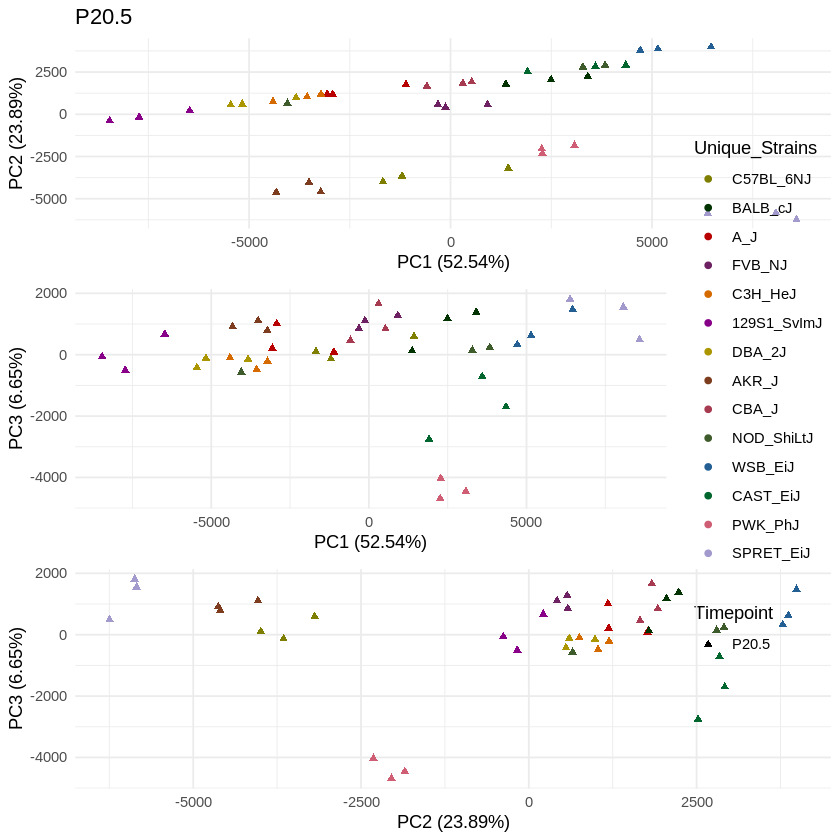

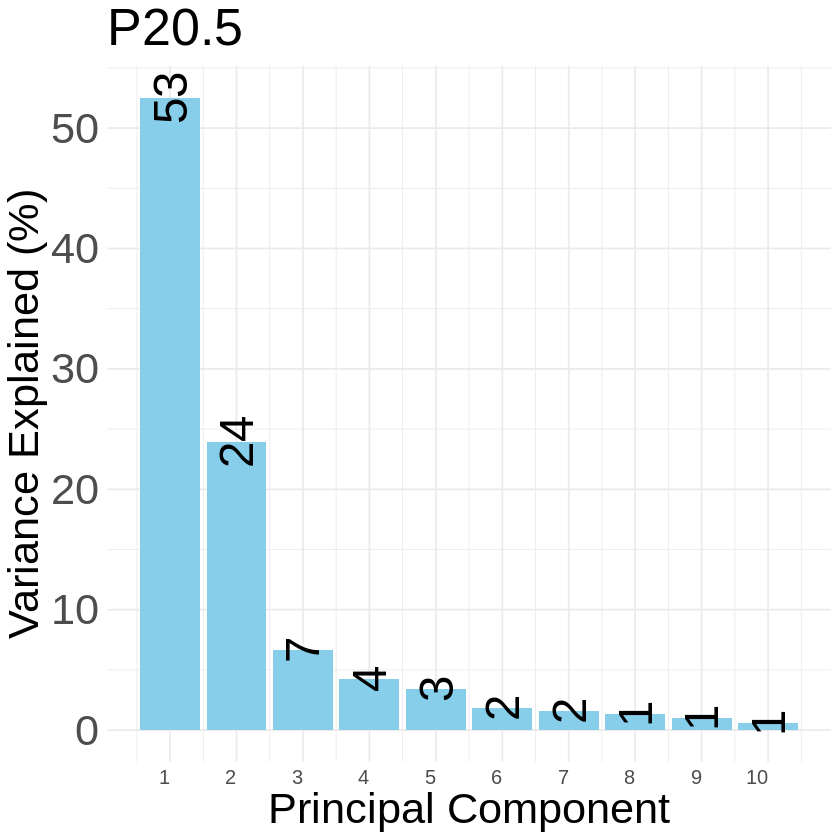

In [43]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)
samplenames <- c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','A_J-P20.5','A_J-P20.5','A_J-P20.5','AKR_J-P20.5',
                 'AKR_J-P20.5','AKR_J-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
                 'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CBA_J-P20.5',
                 'CBA_J-P20.5','CBA_J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
                 'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','SPRET_EiJ-P20.5',
                 'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')


samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')

# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))



# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
num_samples <- length(unique(samplenames))
custom_colors <- rainbow(num_samples)
custom_colors <- c(
  '#7E7E00',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#1F4788'
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P20.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
num_samples <- length(unique(samplenames))
custom_colors <- rainbow(num_samples)
custom_colors <- c(
  '#7E7E00',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#1F4788'
)


# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "P20.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  

pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 






# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("P20.5_edgeR_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "P20.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("P20.5_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

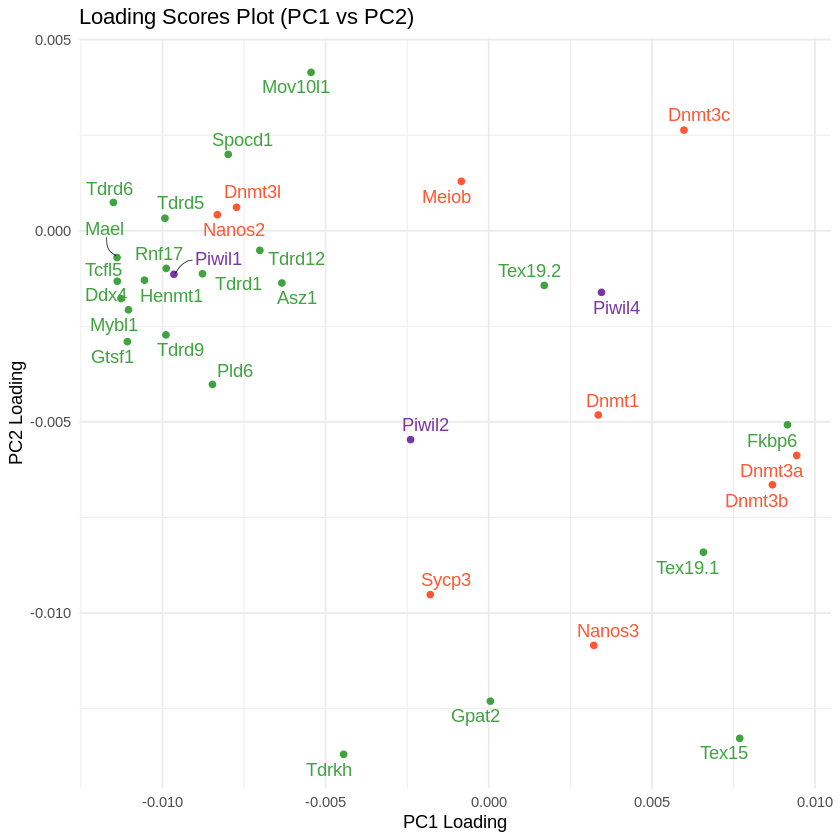

In [46]:
pca_result <- prcomp(t(norm_counts), scale. = TRUE)
loading_scores <- pca_result$rotation

loading_df <- data.frame(Variable = rownames(loading_scores), loading_scores)

# Define the colors for each group
color_palette <- c(
  "#FF5733",   # Bright Orange for the first group
  "#7C36A3",   # Rich Purple for the second group
  "#3FA33F"    # Lively Green for the third group
)
selected_vars <- c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3','Piwil1', 'Piwil2', 'Piwil4',
'Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')
# Extract loading scores for selected variables
selected_loading_df <- loading_df[loading_df$Variable %in% selected_vars, ]


# Define the groups and their corresponding colors
group_colors <- c(
  'Group 1' = "#FF5733",  # Bright Orange
  'Group 2' = "#7C36A3",  # Rich Purple
  'Group 3' = "#3FA33F"   # Lively Green
)

# Create a new column in the data frame to indicate the group each variable belongs to
selected_loading_df$Group <- NA
selected_loading_df$Group[selected_loading_df$Variable %in% c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3')] <- 'Group 1'
selected_loading_df$Group[selected_loading_df$Variable %in% c('Piwil1', 'Piwil2', 'Piwil4')] <- 'Group 2'
selected_loading_df$Group[selected_loading_df$Variable %in% c('Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')] <- 'Group 3'





# Create the scatter plot with colored points based on the groups
loading_scatter_plot <- ggplot(selected_loading_df, aes(x = PC1, y = PC2, label = Variable, color = Group)) +
  geom_point() +
  geom_text_repel(
    force = 5,
    segment.size = 0.2,
    segment.color = "black",
    segment.curvature = 0.2
  ) +
  labs(title = "Loading Scores Plot (PC1 vs PC2)",
       x = "PC1 Loading",
       y = "PC2 Loading") +
  theme_minimal() +
  scale_color_manual(values = group_colors) +
  guides(color = guide_legend(title = "Groups")) +
  theme(legend.position = "none") 


# Display the scatter plot
print(loading_scatter_plot)
ggsave("P20.5_given_gene_loading_scatter_plot.pdf", plot = loading_scatter_plot, width = 20, height = 20)

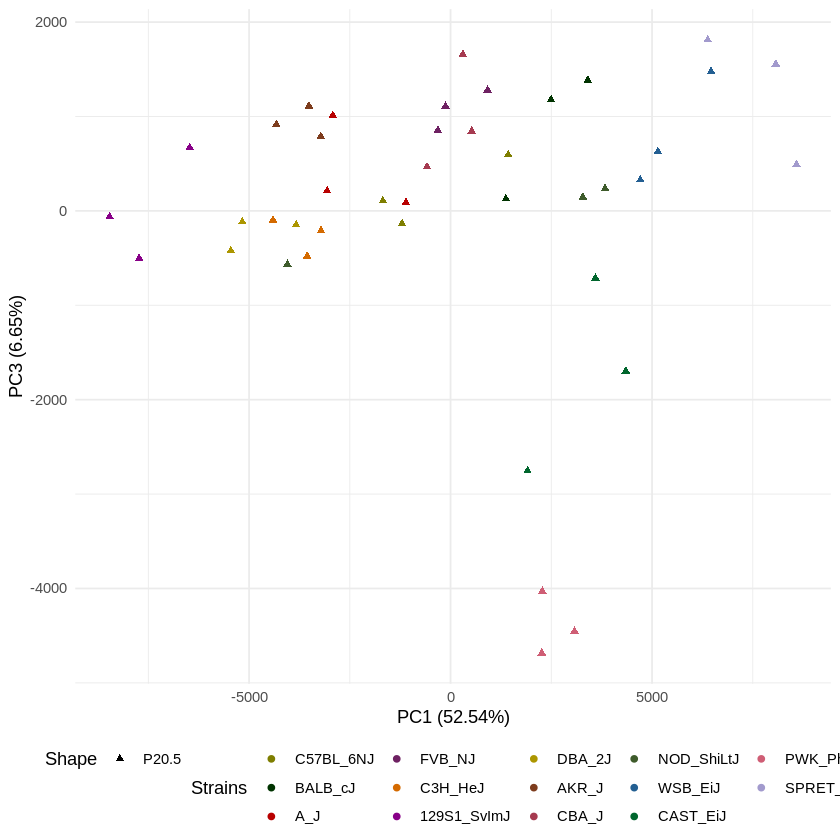

In [36]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0.2, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


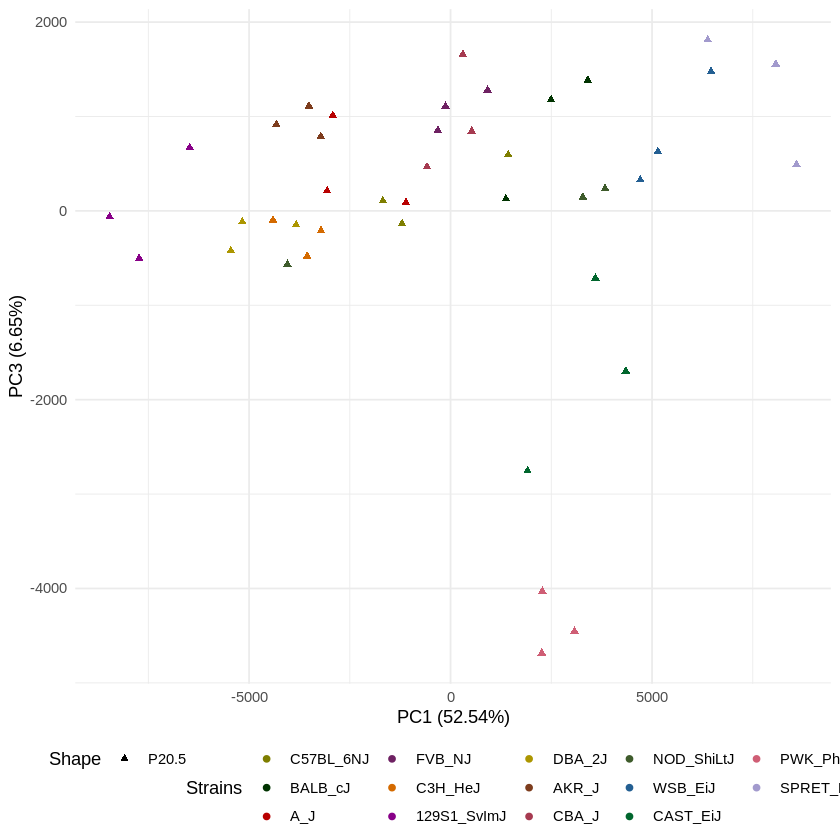

In [37]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P20.5.1,-7180.451970,-405.58636,-594.324341,129S1_SvImJ-P20.5,52.22936,26.51127,6.700331,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,-7888.296591,-634.39766,-170.063267,129S1_SvImJ-P20.5,52.22936,26.51127,6.700331,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,-6172.146065,-49.93963,687.084214,129S1_SvImJ-P20.5,52.22936,26.51127,6.700331,P20.5,129S1_SvImJ
A_J-P20.5.1,-2925.317235,1073.00313,144.613966,A_J-P20.5,52.22936,26.51127,6.700331,P20.5,A_J
A_J-P20.5.2,-2907.031004,1020.67983,1035.731599,A_J-P20.5,52.22936,26.51127,6.700331,P20.5,A_J
A_J-P20.5.3,-1211.340584,1680.39276,-5.792083,A_J-P20.5,52.22936,26.51127,6.700331,P20.5,A_J
AKR_J-P20.5.1,-2993.203195,-4077.37451,1051.953268,AKR_J-P20.5,52.22936,26.51127,6.700331,P20.5,AKR_J
AKR_J-P20.5.2,-2672.740103,-4643.22614,746.137662,AKR_J-P20.5,52.22936,26.51127,6.700331,P20.5,AKR_J
AKR_J-P20.5.3,-3714.332273,-4695.95652,863.450264,AKR_J-P20.5,52.22936,26.51127,6.700331,P20.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


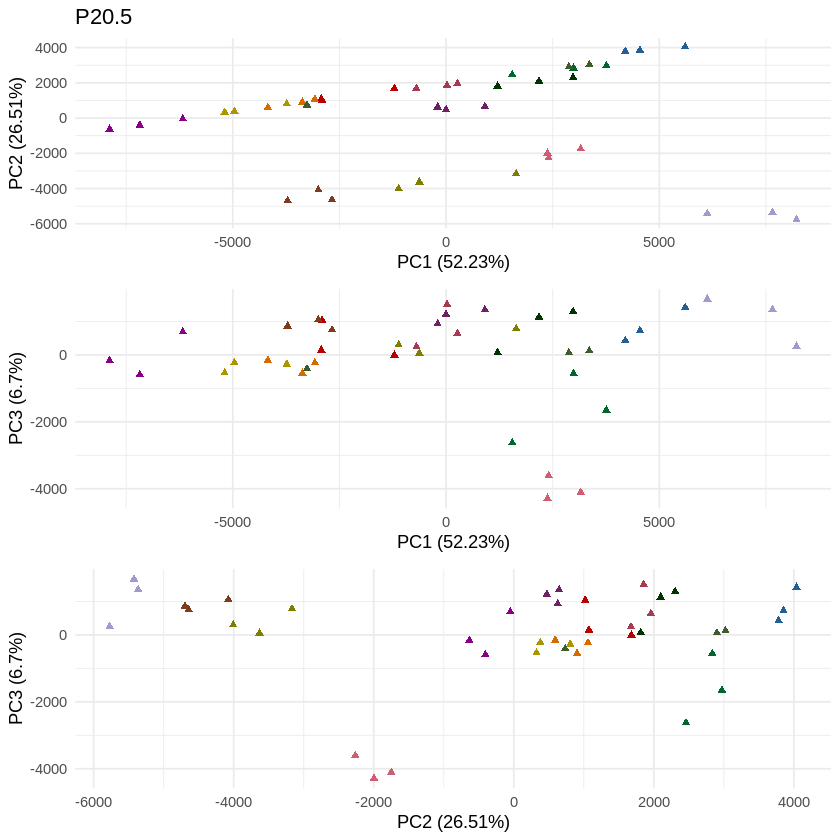

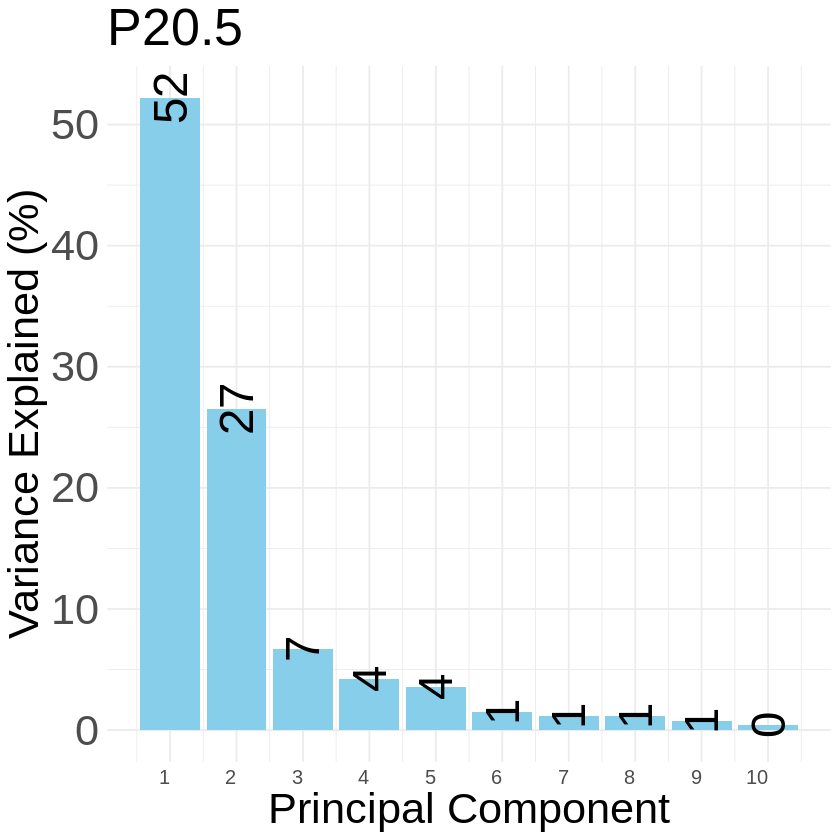

In [38]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
row_variances <- apply(norm_counts, 1, var)
top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
subset_norm_counts <- norm_counts[top_variants, ]

# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))



# Sample data for illustration purposes
set.seed(123)
samplenames <- c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','A_J-P20.5','A_J-P20.5','A_J-P20.5','AKR_J-P20.5',
                 'AKR_J-P20.5','AKR_J-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
                 'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CBA_J-P20.5',
                 'CBA_J-P20.5','CBA_J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
                 'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','SPRET_EiJ-P20.5',
                 'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')


samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')





# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
num_samples <- length(unique(samplenames))
custom_colors <- rainbow(num_samples)
custom_colors <- c(
  '#7E7E00',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#1F4788'
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P20.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
num_samples <- length(unique(samplenames))
custom_colors <- rainbow(num_samples)
custom_colors <- c(
  '#7E7E00',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#1F4788'
)
# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "P20.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
 scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 




# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("P20.5_edgeR_PCA_top_500.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "P20.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("P20.5_variance_explained_bar_plot_top_500.pdf", variance_bar_plot, width = 3, height = 4, units = "in")


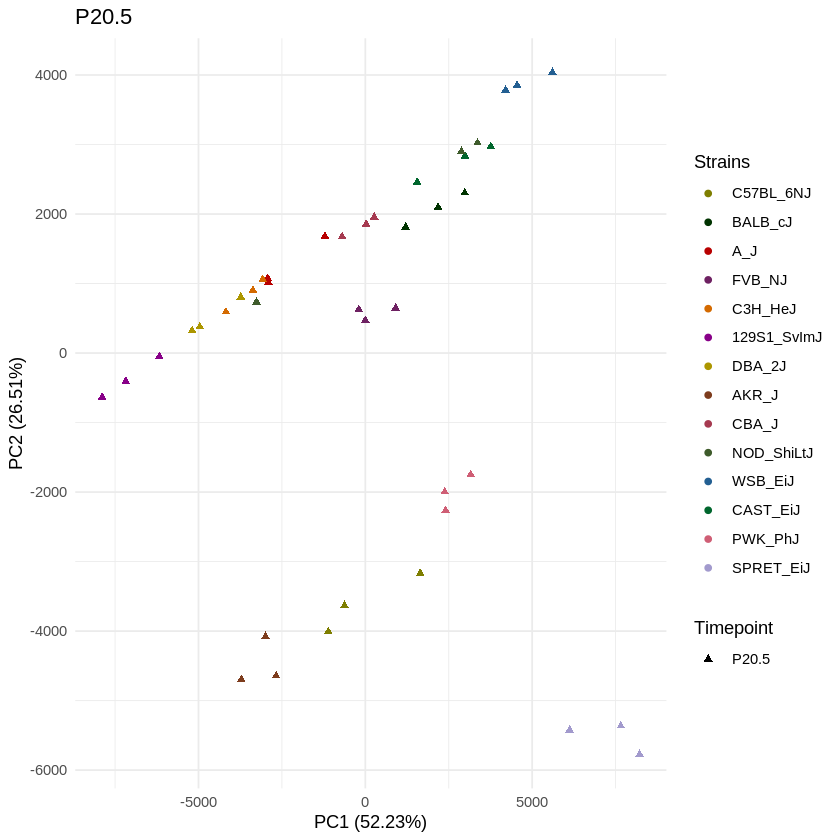

In [39]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "P20.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() + labs(shape = "Timepoint")  +labs(color = "Strains") 
pca_plot_pc1_pc2

In [40]:

#https://sdgamboa.github.io/post/2020_volcano/

pairwise_combinations <- list(
  c( 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'A_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'FVB_NJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'C3H_HeJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', '129S1_SvImJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'DBA_2J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'AKR_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CBA_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'NOD_ShiLtJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CAST_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'PWK_PhJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'SPRET_EiJ-P20.5')
  # Add more contrasts here if needed
)


library(edgeR)
library(EnhancedVolcano)
library(foreach)
library(doParallel)


# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}
# Combine results from all comparisons
all_results <- data.frame()

# Number of cores for parallel processing
num_cores <- 18  # Change this to the desired number of cores

# Set up parallel backend
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Parallelized loop to create and save volcano plots
foreach(pair = pairwise_combinations) %dopar% {
  library(edgeR)
  library(EnhancedVolcano)
    # Load packages
  library(tidyverse)
  library(ggrepel)
  library(kableExtra)
  condition1 <- pair[1]
  condition2 <- pair[2]
  # Subset the data for the specific conditions
  #pair <- c('CAST_EiJ-P20.5', 'SPRET_EiJ-P20.5')
  sub_lables <- paste(pair, c(".1", ".1", ".2",".2", ".3", ".3"), sep = "")
  sub_samples <- sub("\\.\\d$", "", sub_lables) 
  subset_data <-rawdata_copy$counts[,sub_lables]
  dge <- DGEList(counts = subset_data, group = factor(sub_samples))
  keep <- filterByExpr(y = dge)
  dge <- dge[keep,  keep.lib.sizes=FALSE]
  dge <- calcNormFactors(object = dge, method = "TMM")
  dge <- estimateDisp(y = dge)
  et <- exactTest(object = dge)
  top_degs = topTags(object = et, n = "Inf")
  
  data <- data.frame(Genes = rownames(top_degs$table),
                    logFC = top_degs$table$logFC,
                     FDR = top_degs$table$FDR,
                     PValue = top_degs$table$PValue)

  data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.0001 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.0001 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )

    data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.001 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.001 ~ "FDR 0.001", 
          TRUE ~ "Unchanged")
      )

    

    data %>% 
      count(Expression, Significance) 

    top <- 30 # number of to genes 
    top_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top)
    )
    all_top <- 1000
    all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC)))%>% 
        head(all_top) ,
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(all_top)
    )


    comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
    all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = top_genes$Expression,
                                                Significance = top_genes$Significance,
                                                Genes = top_genes$Genes))

    p2 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Expression), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
      guides(colour = guide_legend(override.aes = list(size=1.5)))  + theme_minimal()
    p2 <-  p2 +
      geom_label_repel(data = top_genes,
                      mapping = aes(logFC, -log(FDR,10), label = Genes),
                      size = 2) + ggtitle(paste( condition1, "_vs_", condition2, sep = ""))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_P20.5_up_down_volcano_plot.pdf", sep = ""), width = 6, height = 8)  # Adjust width and height as needed
    print(p2)
    dev.off()  # Close the PDF device

  
    p3 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Significance), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_viridis_d() +
      guides(colour = guide_legend(override.aes = list(size=1.5))) +theme_minimal()
    p3 <-  p3 +
      geom_label_repel(data = top_genes,
                      mapping = aes(logFC, -log(FDR,10), label = Genes),
                      size = 2) + ggtitle(paste( condition1, "_vs_", condition2, sep = ""))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_P20.5_singnificant_volcano_plot.pdf", sep = ""), width = 6, height = 8)  # Adjust width and height as needed
    print(p3)
    dev.off() 



}

all_results
# Stop the parallel backend
stopCluster(cl)


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel



[[1]]
null device 
          1 

[[2]]
null device 
          1 

[[3]]
null device 
          1 

[[4]]
null device 
          1 

[[5]]
null device 
          1 

[[6]]
null device 
          1 

[[7]]
null device 
          1 

[[8]]
null device 
          1 

[[9]]
null device 
          1 

[[10]]
null device 
          1 

[[11]]
null device 
          1 

[[12]]
null device 
          1 

[[13]]
null device 
          1

<0 x 0 matrix>

In [41]:
pairwise_combinations <- list(
  c( 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'A_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'FVB_NJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'C3H_HeJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', '129S1_SvImJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'DBA_2J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'AKR_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CBA_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'NOD_ShiLtJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CAST_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'PWK_PhJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'SPRET_EiJ-P20.5')
  # Add more contrasts here if needed
)

library(edgeR)
library(EnhancedVolcano)
library(tidyverse)
library(ggrepel)
library(kableExtra)

# Combine results from all comparisons
all_results <- data.frame()

# Loop through pairwise combinations
for (pair in pairwise_combinations) {
  condition1 <- pair[1]
  condition2 <- pair[2]
  
  # Subset the data for the specific conditions
  sub_labels <- paste(pair, c(".1", ".1", ".2",".2", ".3", ".3"), sep = "")
  sub_samples <- sub("\\.\\d$", "", sub_labels)
  subset_data <- rawdata_copy$counts[, sub_labels]
  dge <- DGEList(counts = subset_data, group = factor(sub_samples))
  keep <- filterByExpr(y = dge)
  dge <- dge[keep,  keep.lib.sizes = FALSE]
  dge <- calcNormFactors(object = dge, method = "TMM")
  dge <- estimateDisp(y = dge)
  et <- exactTest(object = dge)
  top_degs <- topTags(object = et, n = "Inf")
  
  data <- data.frame(Genes = rownames(top_degs$table),
                    logFC = top_degs$table$logFC,
                     FDR = top_degs$table$FDR,
                     PValue = top_degs$table$PValue)

  
   data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.0001 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.0001 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )

    data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.001 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.001 ~ "FDR 0.001", 
          TRUE ~ "Unchanged")
      )

    

    top <- 30 # number of to genes 
    top_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top)
    )
    all_top <- 1000
    all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC)))
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC)))
    )

    comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
    all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = all_genes$Expression,
                                                Significance = all_genes$Significance,
                                                Genes = all_genes$Genes))

}

# Print or use all_results as needed
print(all_results)


ERROR: Error in parse(text = x, srcfile = src): <text>:84:7: unexpected symbol
83:         arrange(FDR, desc(abs(logFC)))
84:       data
          ^


In [ ]:
all_results

Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm20594
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Myef2l
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Nphs1
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm38056
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Trim30d
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Olfr617
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Olfr1033
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm44510
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Rab44


In [ ]:
# Combine top_genes data from all comparisons
combined_top_genes <-  all_results
combined_top_genes



Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm20594
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Myef2l
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Nphs1
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm38056
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Trim30d
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Olfr617
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Olfr1033
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Gm44510
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,Up-regulated,FDR 0.001,Rab44


In [ ]:
library(ggplot2)

# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)
summary_data
pair_sets <- c("C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5",
  "C57BL_6NJ-P20.5_vs_A_J-P20.5",
  "C57BL_6NJ-P20.5_vs_FVB_NJ-P20.5",
  "C57BL_6NJ-P20.5_vs_C3H_HeJ-P20.5",
  "C57BL_6NJ-P20.5_vs_129S1_SvImJ-P20.5",
  "C57BL_6NJ-P20.5_vs_DBA_2J-P20.5",
  "C57BL_6NJ-P20.5_vs_AKR_J-P20.5",
  "C57BL_6NJ-P20.5_vs_CBA_J-P20.5",
  "C57BL_6NJ-P20.5_vs_NOD_ShiLtJ-P20.5",
  "C57BL_6NJ-P20.5_vs_WSB_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_CAST_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_PWK_PhJ-P20.5",
  "C57BL_6NJ-P20.5_vs_SPRET_EiJ-P20.5")

# Create separate plots for upregulated and downregulated genes
upregulated_plot <- ggplot(summary_data, aes(x =  factor(Comparison, levels = pair_sets),, y = `Up-regulated`, fill = "Up-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Up-regulated" = "blue")) +
  xlab("Pair Comparison") +
  ylab("# of Up-regulated Genes") +
  ggtitle("# of Up-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom")+
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`), vjust = -0.3, size = 3, color = "black") 

downregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Down-regulated`, fill = "Down-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Down-regulated" = "red")) +
  xlab("Pair Comparison") +
  ylab("# of Significant-Down-regulated Genes") +
  ggtitle("# of Significant-Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`), vjust = -0.3, size = 3, color = "black")

# Print the separate plots
# Open a PDF device to save the plot
pdf("P20.5_upreglated_count_bar_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed
print(upregulated_plot)
dev.off()
pdf("P20.5_downreglated_count_bar_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed
print(downregulated_plot)
dev.off()


Comparison,Down-regulated,Up-regulated
<chr>,<dbl>,<dbl>
C57BL_6NJ-P20.5_vs_129S1_SvImJ-P20.5,446,546
C57BL_6NJ-P20.5_vs_A_J-P20.5,326,340
C57BL_6NJ-P20.5_vs_AKR_J-P20.5,519,342
C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5,535,849
C57BL_6NJ-P20.5_vs_C3H_HeJ-P20.5,371,362
C57BL_6NJ-P20.5_vs_CAST_EiJ-P20.5,1000,1000
C57BL_6NJ-P20.5_vs_CBA_J-P20.5,408,459
C57BL_6NJ-P20.5_vs_DBA_2J-P20.5,396,408
C57BL_6NJ-P20.5_vs_FVB_NJ-P20.5,317,349


png 
  2

png 
  2

In [ ]:
unique(combined_top_genes$Comparison)

[1] "C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5"    
 [2] "C57BL_6NJ-P20.5_vs_A_J-P20.5"        
 [3] "C57BL_6NJ-P20.5_vs_FVB_NJ-P20.5"     
 [4] "C57BL_6NJ-P20.5_vs_C3H_HeJ-P20.5"    
 [5] "C57BL_6NJ-P20.5_vs_129S1_SvImJ-P20.5"
 [6] "C57BL_6NJ-P20.5_vs_DBA_2J-P20.5"     
 [7] "C57BL_6NJ-P20.5_vs_AKR_J-P20.5"      
 [8] "C57BL_6NJ-P20.5_vs_CBA_J-P20.5"      
 [9] "C57BL_6NJ-P20.5_vs_NOD_ShiLtJ-P20.5" 
[10] "C57BL_6NJ-P20.5_vs_WSB_EiJ-P20.5"    
[11] "C57BL_6NJ-P20.5_vs_CAST_EiJ-P20.5"   
[12] "C57BL_6NJ-P20.5_vs_PWK_PhJ-P20.5"    
[13] "C57BL_6NJ-P20.5_vs_SPRET_EiJ-P20.5"

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_upregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

pair_sets <- c("C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5",
  "C57BL_6NJ-P20.5_vs_A_J-P20.5",
  "C57BL_6NJ-P20.5_vs_FVB_NJ-P20.5",
  "C57BL_6NJ-P20.5_vs_C3H_HeJ-P20.5",
  "C57BL_6NJ-P20.5_vs_129S1_SvImJ-P20.5",
  "C57BL_6NJ-P20.5_vs_DBA_2J-P20.5",
  "C57BL_6NJ-P20.5_vs_AKR_J-P20.5",
  "C57BL_6NJ-P20.5_vs_CBA_J-P20.5",
  "C57BL_6NJ-P20.5_vs_NOD_ShiLtJ-P20.5",
  "C57BL_6NJ-P20.5_vs_WSB_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_CAST_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_PWK_PhJ-P20.5",
  "C57BL_6NJ-P20.5_vs_SPRET_EiJ-P20.5")
library(UpSetR)

# Open a PDF device to save the plot
pdf("P20.5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_sets ,nsets = 13,point.size = 2, line.size = 2,keep.order = TRUE,
    mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 7) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


png 
  2

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)
library(UpSetR)

# Filter data for common upregulated and downregulated genes
common_downregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_downregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

pair_sets <- c("C57BL_6NJ-P20.5_vs_BALB_cJ-P20.5",
  "C57BL_6NJ-P20.5_vs_A_J-P20.5",
  "C57BL_6NJ-P20.5_vs_FVB_NJ-P20.5",
  "C57BL_6NJ-P20.5_vs_C3H_HeJ-P20.5",
  "C57BL_6NJ-P20.5_vs_129S1_SvImJ-P20.5",
  "C57BL_6NJ-P20.5_vs_DBA_2J-P20.5",
  "C57BL_6NJ-P20.5_vs_AKR_J-P20.5",
  "C57BL_6NJ-P20.5_vs_CBA_J-P20.5",
  "C57BL_6NJ-P20.5_vs_NOD_ShiLtJ-P20.5",
  "C57BL_6NJ-P20.5_vs_WSB_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_CAST_EiJ-P20.5",
  "C57BL_6NJ-P20.5_vs_PWK_PhJ-P20.5",
  "C57BL_6NJ-P20.5_vs_SPRET_EiJ-P20.5")
library(UpSetR)

# Open a PDF device to save the plot
pdf("P20.5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_sets ,nsets = 13,point.size = 2, line.size = 2,keep.order = TRUE,
    mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 7) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()



png 
  2

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
pairwise_combinations <- list(
  c( 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'A_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'FVB_NJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'C3H_HeJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', '129S1_SvImJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'DBA_2J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'AKR_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CBA_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'NOD_ShiLtJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CAST_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'PWK_PhJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'CAST_EiJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'WSB_EiJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'CAST_EiJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'NOD_ShiLtJ-P20.5', 'SPRET_EiJ-P20.5'),
  c('WSB_EiJ-P20.5', 'PWK_PhJ-P20.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Up-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation








In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]

  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 5, width = 8)
}


Warning message:
“Removed 10 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”


ERROR: Error in order(...): argument 1 is not a vector


In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
pairwise_combinations <- list(
  c( 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'A_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'FVB_NJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'C3H_HeJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', '129S1_SvImJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'DBA_2J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'AKR_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CBA_J-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'NOD_ShiLtJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'CAST_EiJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'PWK_PhJ-P20.5'),
  c( 'C57BL_6NJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'CAST_EiJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'WSB_EiJ-P20.5', 'SPRET_EiJ-P20.5'),
  c( 'CAST_EiJ-P20.5', 'WSB_EiJ-P20.5'),
  c( 'NOD_ShiLtJ-P20.5', 'SPRET_EiJ-P20.5'),
  c('WSB_EiJ-P20.5', 'PWK_PhJ-P20.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Down-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation





In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]

  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 5, width = 8)
}


Warning message:
“Removed 1 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 9 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
